# 07 GPU 30-Day Daywise Monthly Price Forecaster
Supply any GPU name (e.g. `Gigabyte Eagle Max GeForce RTX 5060 Ti 16GB GDDR7 OC Triple Fan`), resolve catalog SKU metadata, and generate a day-by-day 30-day forecast table with lower/upper confidence bounds, MSRP premium ratios, and a visual line graph.

In [6]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Add workspace dir to sys.path
workspace_dir = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(workspace_dir) not in sys.path:
    sys.path.insert(0, str(workspace_dir))

from src.daywise_forecaster import forecast_gpu_month_daywise, resolve_gpu_identifier
from src.io_utils import load_sample_dataset
from src.clean_prices import clean_price_observations
from src.normalize_prices import normalize_price_series

## 1. Supply GPU Name & Run 30-Day Daywise Forecaster

In [7]:
gpu_input_name = "Gigabyte Eagle Max GeForce RTX 5060 Ti 16GB GDDR7 OC Triple Fan"

# Run 30-day daywise forecaster
result = forecast_gpu_month_daywise(gpu_input_name, horizon_days=30)
gpu_meta = result["gpu_info"]
forecast_df = result["forecast_df"]

# Load historical normalized observations for plotting
products_df = load_sample_dataset("products.csv")
listings_df = load_sample_dataset("product_listings.csv")
obs_df = load_sample_dataset("daily_price_observations.csv")
cleaned_obs = clean_price_observations(obs_df)
norm_df = normalize_price_series(cleaned_obs, listings_df, products_df)

## 2. Product Summary & 30-Day Outlook

In [8]:
print("===========================================================")
print(f"📌 Target GPU: {gpu_meta['model_name']}")
print(f"   SKU ID: {gpu_meta['sku_id']} | Brand: {gpu_meta['brand']} | VRAM: {gpu_meta['vram_gb']}GB {gpu_meta['vram_type']}")
print(f"   MSRP: ₹{gpu_meta['msrp_inr']:,.2f}")
print("-----------------------------------------------------------")
print(f"   Current Market Price ({result['last_observed_date']}): ₹{result['current_price_inr']:,.2f}")
print(f"   30-Day Forecasted Price: ₹{result['end_of_month_forecast_inr']:,.2f} ({result['monthly_price_change_pct']:+.2f}%)")
print(f"   30-Day Forecast Range: ₹{result['monthly_min_forecast_inr']:,.2f} to ₹{result['monthly_max_forecast_inr']:,.2f}")
print(f"   Recommended Action (7d): [{result['signal_7d']['recommended_action']}]")
print(f"   Rationale: {result['signal_7d']['rationale']}")
print("===========================================================")

📌 Target GPU: Gigabyte Eagle Max GeForce RTX 5060 Ti 16GB GDDR7 OC Triple Fan
   SKU ID: RTX5060TI-16G-GIGA-EAGLE | Brand: Gigabyte | VRAM: 16GB GDDR7
   MSRP: ₹51,999.00
-----------------------------------------------------------
   Current Market Price (2026-07-30): ₹82,150.00
   30-Day Forecasted Price: ₹96,845.35 (+17.89%)
   30-Day Forecast Range: ₹83,030.04 to ₹96,845.35
   Recommended Action (7d): [WAIT]
   Rationale: Current price (₹82,150) remains above MSRP/target. Forecast expects minimal immediate drop (6.6%).


## 3. 30-Day Daywise Price Forecast Table

In [9]:
display(forecast_df[["day_index", "date", "forecasted_price_inr", "lower_bound_inr", "upper_bound_inr", "msrp_premium_ratio", "expected_change_pct"]])

,day_index,date,forecasted_price_inr,lower_bound_inr,upper_bound_inr,msrp_premium_ratio,expected_change_pct
0,1,2026-07-31,83030.04,80846.69,85213.39,1.5968,1.07
1,2,2026-08-01,83874.88,80787.15,86962.61,1.6130,2.10
2,3,2026-08-02,84685.57,80903.89,88467.25,1.6286,3.09
3,4,2026-08-03,85463.15,81096.45,89829.85,1.6436,4.03
4,5,2026-08-04,86208.60,81326.48,91090.72,1.6579,4.94
5,6,2026-08-05,86922.92,81574.82,92271.02,1.6716,5.81
6,7,2026-08-06,87607.04,81830.43,93383.65,1.6848,6.64
7,8,2026-08-07,88261.88,82086.43,94437.33,1.6974,7.44
8,9,2026-08-08,88888.35,82338.29,95438.41,1.7094,8.20
9,10,2026-08-09,89487.31,82582.94,96391.68,1.7209,8.93


## 3.1 Daywise Price Forecast Line Graph & Confidence Band

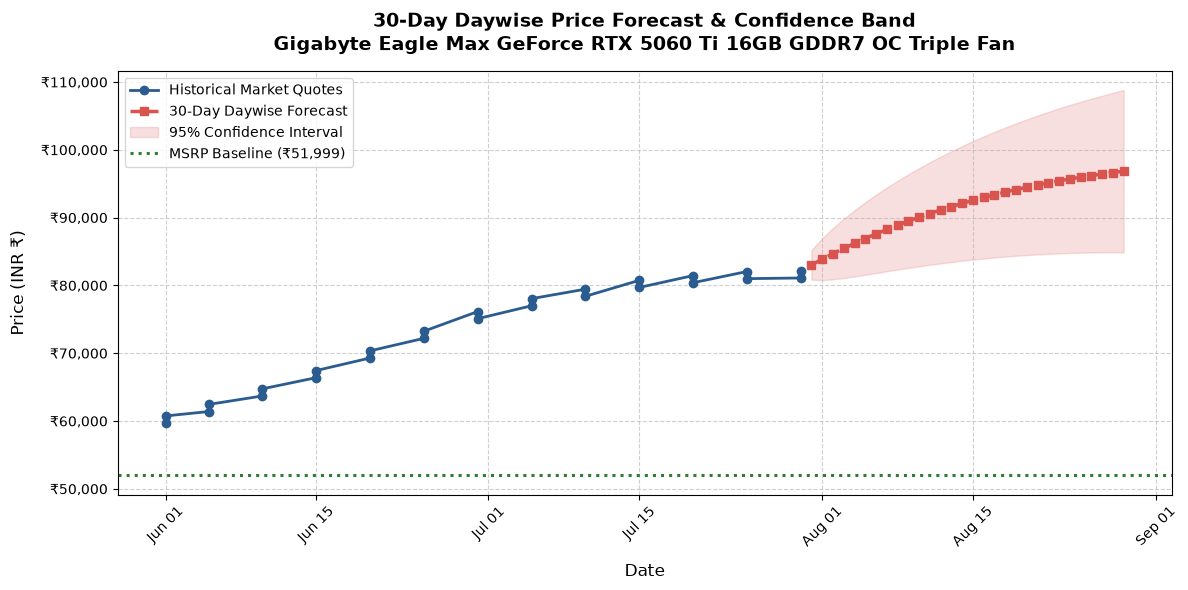

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

# 1. Plot Historical Observations
obs_history = norm_df[norm_df["sku_id"] == gpu_meta["sku_id"]].sort_values("date")
if not obs_history.empty:
    hist_dates = pd.to_datetime(obs_history["date"])
    ax.plot(hist_dates, obs_history["total_effective_price_inr"], marker="o", color="#2b5c8f", label="Historical Market Quotes", linewidth=2)

# 2. Plot 30-Day Daywise Forecast
fc_dates = pd.to_datetime(forecast_df["date"])
ax.plot(fc_dates, forecast_df["forecasted_price_inr"], marker="s", linestyle="--", color="#d9534f", label="30-Day Daywise Forecast", linewidth=2.5)

# 3. Shaded 95% Confidence Interval Band
ax.fill_between(
    fc_dates,
    forecast_df["lower_bound_inr"],
    forecast_df["upper_bound_inr"],
    color="#d9534f",
    alpha=0.18,
    label="95% Confidence Interval"
)

# 4. Baseline MSRP Line
ax.axhline(y=gpu_meta["msrp_inr"], color="#2e7d32", linestyle=":", linewidth=2.2, label=f"MSRP Baseline (₹{gpu_meta['msrp_inr']:,.0f})")

ax.set_title(f"30-Day Daywise Price Forecast & Confidence Band\n{gpu_meta['model_name']}", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Date", fontsize=12, labelpad=10)
ax.set_ylabel("Price (INR ₹)", fontsize=12, labelpad=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter("₹{x:,.0f}")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

## 4. Run Batch 30-Day Daywise Forecast Across All Catalog GPUs

In [11]:
summary_rows = []

for _, p in products_df.iterrows():
    res = forecast_gpu_month_daywise(p["sku_id"], horizon_days=30)
    summary_rows.append({
        "sku_id": p["sku_id"],
        "model_name": p["model_name"],
        "msrp_inr": p["msrp_inr"],
        "current_price_inr": res["current_price_inr"],
        "forecast_30d_inr": res["end_of_month_forecast_inr"],
        "monthly_change_pct": res["monthly_price_change_pct"],
        "recommended_action": res["signal_7d"]["recommended_action"],
    })

batch_df = pd.DataFrame(summary_rows)
display(batch_df)

,sku_id,model_name,msrp_inr,current_price_inr,forecast_30d_inr,monthly_change_pct,recommended_action
0,RTX5060TI-16G-GIGA-GAMING,GeForce RTX 5060 Ti Gaming OC 16GB,49999,87150.0,98196.06,12.67,WAIT
1,RTX5060TI-8G-MSI-VENTUS,GeForce RTX 5060 Ti Ventus 2X 8GB,41999,72200.0,85095.25,17.86,WAIT
2,RTX5070-12G-ASUS-TUF,TUF Gaming GeForce RTX 5070 12GB,64999,112500.0,154775.03,37.58,WAIT
3,RTX5070TI-16G-ZOTAC-TRIN,Gaming GeForce RTX 5070 Ti Trinity 16GB,84999,146750.0,201298.43,37.17,WAIT
4,RTX5060TI-16G-ASUS-DUAL,ASUS Dual GeForce RTX 5060 Ti 16GB GDDR7 OC Ed...,49999,89150.0,105481.80,18.32,WAIT
5,RTX5060TI-16G-MSI-SHADOW,MSI Shadow GeForce RTX 5060 Ti 16GB GDDR7 2X OC,48999,88500.0,104864.53,18.49,WAIT
6,RTX5060TI-16G-GIGA-EAGLE,Gigabyte Eagle Max GeForce RTX 5060 Ti 16GB GD...,51999,82150.0,96845.35,17.89,WAIT
